Survived: Whether a passenger survived or not (0 = No, 1 = Yes).
Pclass: A proxy for socio-economic status, with 1 being 1st class, 2 being 2nd class, and 3 being 3rd class.
Name: The passenger's full name.
Sex: The gender of the passenger (male or female).
Age: The age of the passenger in years.
SibSp: The number of siblings or spouses aboard the Titanic.
Parch: The number of parents or children aboard the Titanic.
Ticket: The ticket number.
Fare: The amount of money the passenger paid for their ticket.
Cabin: The cabin number.
Embarked: The port where the passenger boarded the ship (e.g., Cherbourg, Queenstown, Southampton).
PassengerId: A unique identifier for each passenger. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\HP\Downloads\archive (4)\Titanic-Dataset.csv")

# DATA INFO (EDA)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.shape #rows and columns

(891, 12)

In [7]:
df.info() #to checks nulls and dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.columns #to check columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
df.describe() #numeric data

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.describe(include="object") #categorical data

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [11]:
df.isnull().sum() #columns with missing data

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df.isnull().sum()/df.shape[0]*100 #percentage of null values per column

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [13]:
df.duplicated().sum() #to check duplicate values

0

<Axes: >

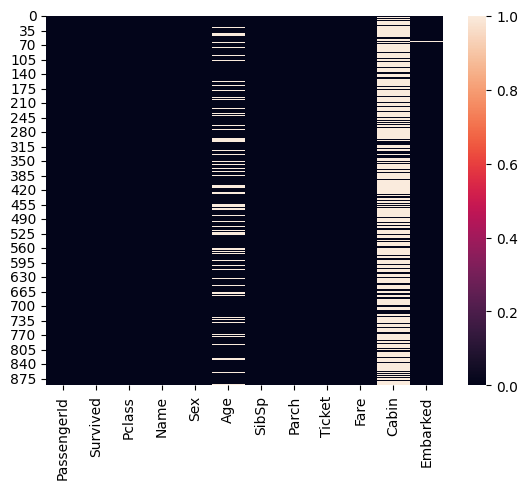

In [14]:
sns.heatmap(df.isnull()) #columns with null values visualised

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

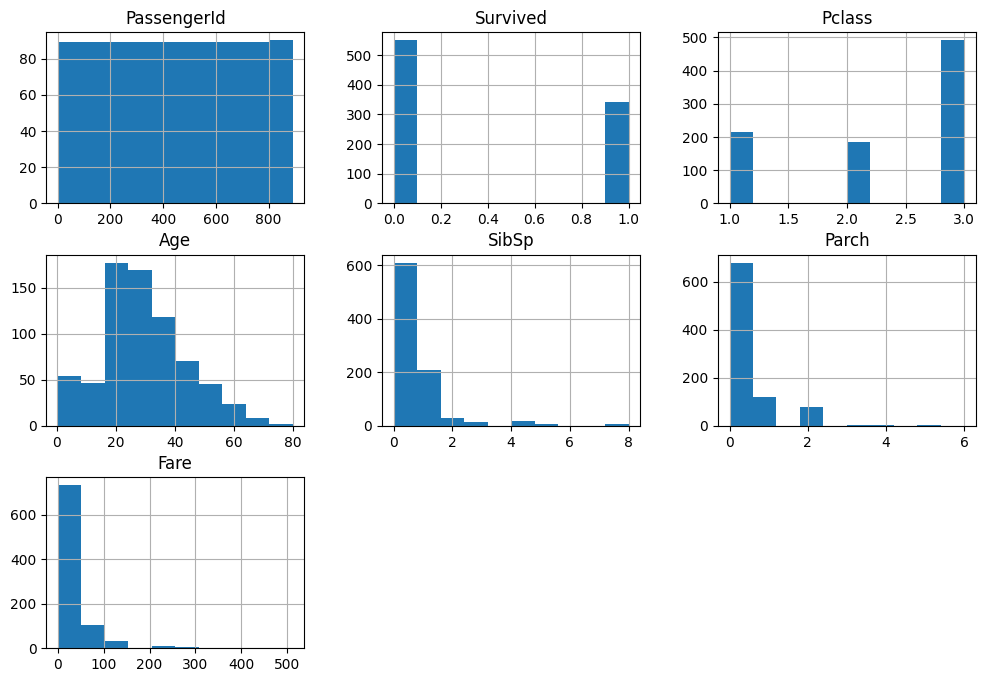

In [15]:
df.hist(figsize=(12,8)) #to check skewness, kurtosis and anomalies

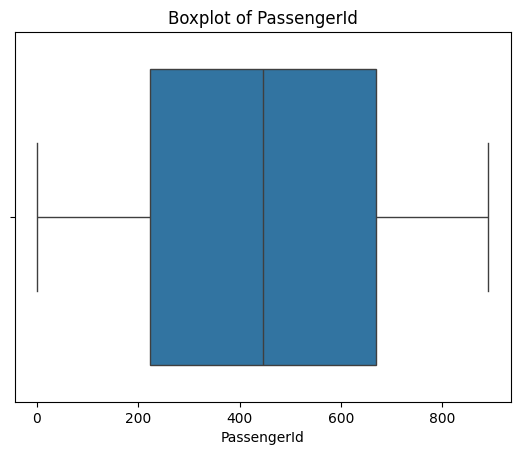

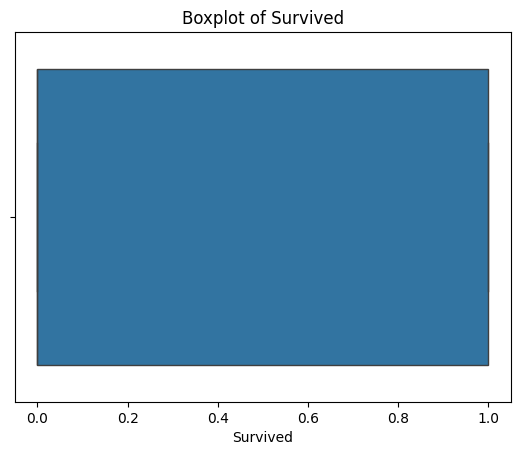

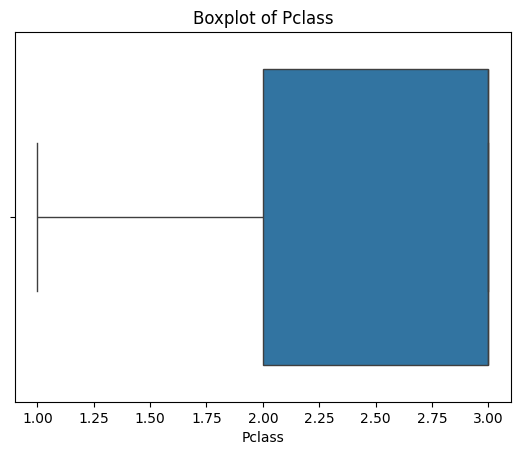

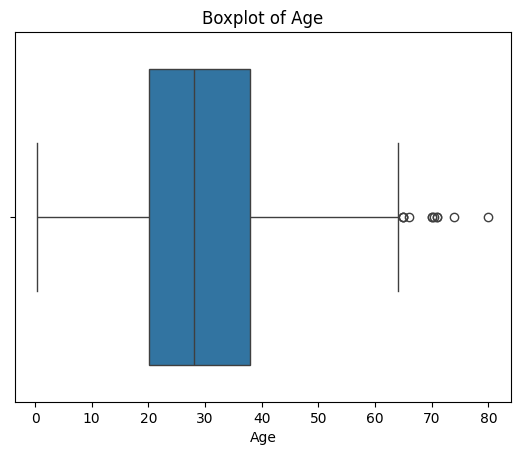

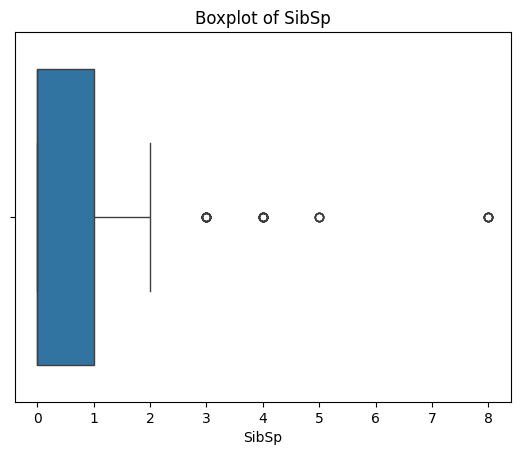

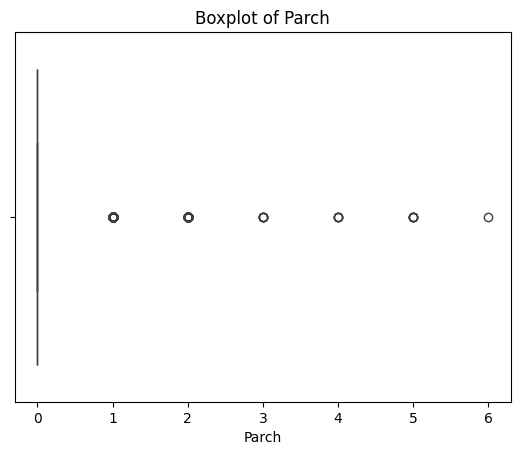

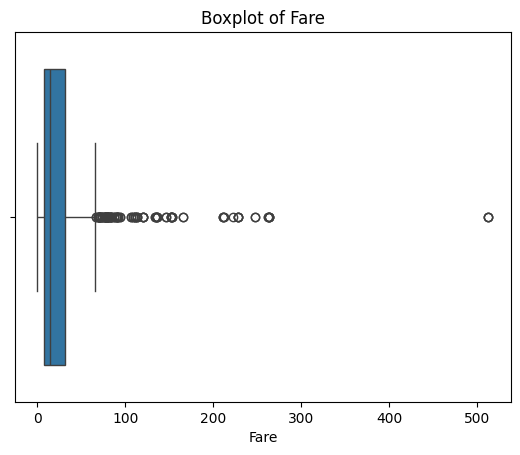

In [17]:
for col in df.select_dtypes(include="number"):
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show() #to see outliers

In [18]:
pd.crosstab(df["Sex"],df["Embarked"]) #association between Sex and Embarked

Embarked,C,Q,S
Sex,,,
female,73,36,203
male,95,41,441


In [19]:
df.skew(numeric_only = True) #high skewness when >|1|

PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.389108
SibSp          3.695352
Parch          2.749117
Fare           4.787317
dtype: float64

# Handling Missing Values
Techniques-
1. df.dropna() BEFORE TRAIN-TEST SPLIT
2. df.fillna(method="bfill")
3. df.fillna(method="ffill")
4. df["column_name"].fillna(df["column_name"].mode()[0])
5. si = SimpleImputer(strategy="mean")
   ar = si.fit_transform(df["column_name"])
   strategies can be 'mean','median','most_frequent','constant'
   constant comes with 'fill_value' parameter
   
3 columns have missing values- Age, Cabin, Embarked
Age- about 20% data is missing, fill it with the median value.
Cabin- about 70% data is missing, drop this column.
Embarked- about 0.22% data is missing, fill it with the mode value.

In [20]:
#drop the cabin column (too many missing rows)
df.drop("Cabin",axis=1,inplace=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [21]:
#Remove unnecessary columns
df.drop(["PassengerId","Ticket"],axis=1,inplace=True)
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C


# Train-Test Split
80-20 split: most common
70-30 split: small datasets
90-10 split: large datasets
60-20-20 split: train-validation-test

Step1: Divide data into x and y (indep and dep)
if indep is at last: 
x=df.iloc[:,:-1]
y=df["outcome"]
if not: write all columns

Step2: train-test-split: does only one split, very simple and fast. might lead to misleading results.
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

OR

K-Fold Cross Validation: split into K folds, each fold gets a turn as the test set, remaining K-1 used for training. Process repeated K times and average result is taken.
from sklearn.model_selection import KFold
kf = KFold(n_splits=5,shuffle=True,random_state=42)

OR

Straified K-Fold Cross Validation: same as K-Fold but keep the same class ratio in every fold. Used for classification problem.
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [22]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C


In [23]:
#Step-1
x = df.loc[:, df.columns != "Survived"]
y = df["Survived"]
x.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')

In [76]:
#train-test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42,stratify=y)
df.shape,x_train.shape,x_test.shape,y_train.shape,y_test.shape

((891, 9), (668, 8), (223, 8), (668,), (223,))

In [77]:
#KFold CV
from sklearn.model_selection import KFold
kf = KFold(n_splits=5,shuffle=True,random_state=42)

In [78]:
#Stratified KFold CV
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [79]:
from sklearn.impute import SimpleImputer

In [80]:
#fill age with median value
si = SimpleImputer(strategy="median")
si_fit = si.fit(x_train[["Age"]])
x_train["Age"] = si_fit.transform(x_train[["Age"]])
x_test["Age"] = si_fit.transform(x_test[["Age"]])

In [81]:
#fill embarked with most frequent value
si = SimpleImputer(strategy="most_frequent")
si_fit = si.fit(x_train[["Embarked"]])
x_train["Embarked"] = si_fit.transform(x_train[["Embarked"]]).ravel()
x_test["Embarked"] = si_fit.transform(x_test[["Embarked"]]).ravel() #ravel() is used to flatten the array

In [82]:
x_train.isnull().sum() #null values are handled

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [83]:
x_test.isnull().sum()

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

# Replace and change data type
1. replace() method to replace any specific values
2. astype() method to convert data type

For this data, replace won't be used.
astype is used to convert Pclass, Sex and Embarked into Categorical type.

In [84]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 486 to 821
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    668 non-null    int64  
 1   Name      668 non-null    object 
 2   Sex       668 non-null    object 
 3   Age       668 non-null    float64
 4   SibSp     668 non-null    int64  
 5   Parch     668 non-null    int64  
 6   Fare      668 non-null    float64
 7   Embarked  668 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 47.0+ KB


In [85]:
x_train[["Pclass","Sex","Embarked"]]=x_train[["Pclass","Sex","Embarked"]].astype("category")
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 486 to 821
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Pclass    668 non-null    category
 1   Name      668 non-null    object  
 2   Sex       668 non-null    category
 3   Age       668 non-null    float64 
 4   SibSp     668 non-null    int64   
 5   Parch     668 non-null    int64   
 6   Fare      668 non-null    float64 
 7   Embarked  668 non-null    category
dtypes: category(3), float64(2), int64(2), object(1)
memory usage: 33.6+ KB


In [86]:
x_test[["Pclass","Sex","Embarked"]]=x_test[["Pclass","Sex","Embarked"]].astype("category")
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223 entries, 157 to 639
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Pclass    223 non-null    category
 1   Name      223 non-null    object  
 2   Sex       223 non-null    category
 3   Age       223 non-null    float64 
 4   SibSp     223 non-null    int64   
 5   Parch     223 non-null    int64   
 6   Fare      223 non-null    float64 
 7   Embarked  223 non-null    category
dtypes: category(3), float64(2), int64(2), object(1)
memory usage: 11.5+ KB


# Handling Duplicate Data
-> df.drop_duplicates(keep="first",inplace=True)

In [87]:
x_train["Duplicated"]=x_train.duplicated()

In [88]:
x_train["Duplicated"].unique() #each entry is false thus no duplicate value

array([False])

In [89]:
x_train.drop("Duplicated",axis=1,inplace=True)

In [90]:
x_train.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')

In [91]:
x_test["Duplicated"]=x_test.duplicated()

In [92]:
x_test["Duplicated"].unique() #each entry is false thus no duplicate value

array([False])

In [93]:
x_test.drop("Duplicated",axis=1,inplace=True)

In [94]:
x_test.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')

# Outlier
Detect using boxplot-
sns.boxplot(x="",data=df)
1. Remove using IQR- Used when data is not normal and skewed, particularly for small datasets.
q1=df[].quantile(0.25)
q3=df[].quantile(0.75)
iqr = q3-q1
min_range = q1-(1.5*iqr)
max_range = q1+(1.5*iqr)
2. Remove using z score- Used when data is normal and standardised, particularly for large datasets.
z_score = (df[]-df[].mean())/df[].std()

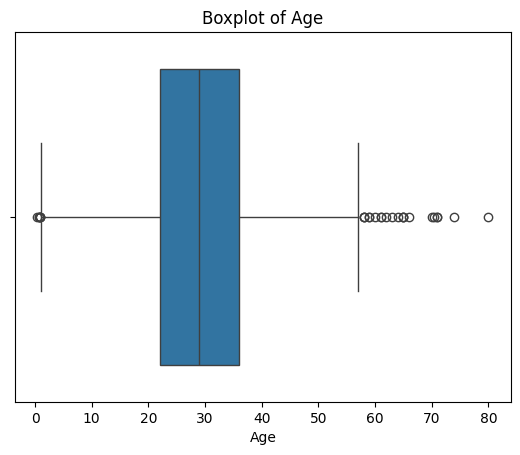

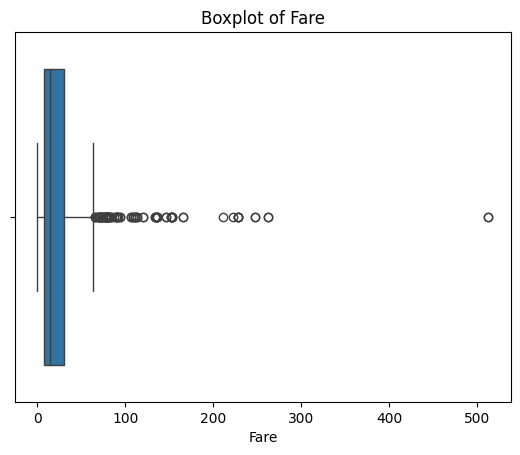

In [95]:
for col in x_train[["Age","Fare"]]:
    sns.boxplot(x=x_train[col])
    plt.title(f"Boxplot of {col}")
    plt.show() #boxplot before handling outliers

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

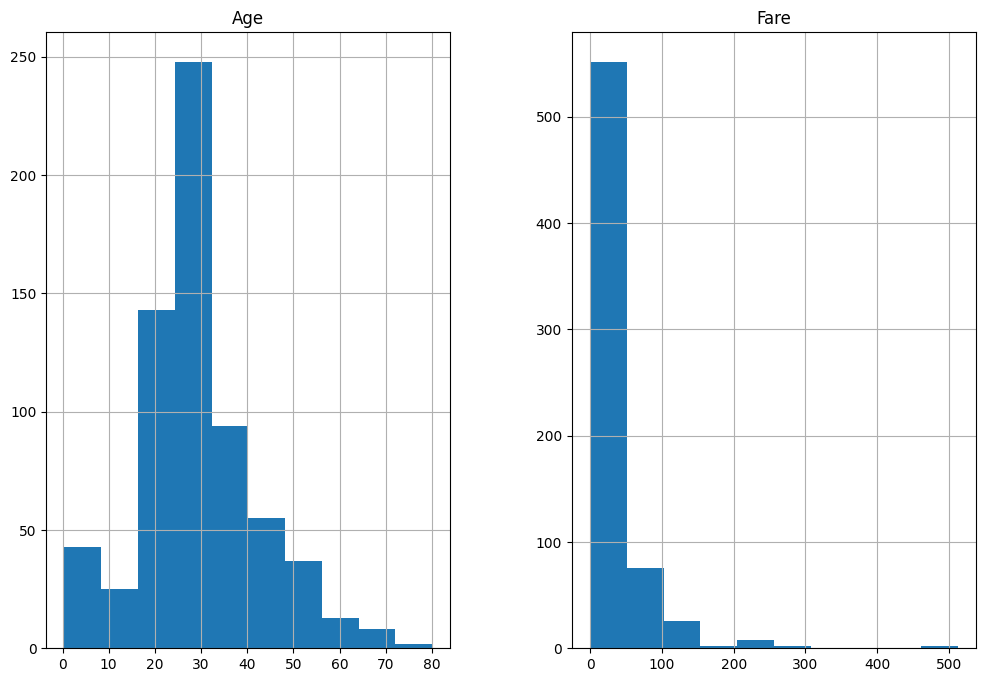

In [96]:
x_train[["Age","Fare"]].hist(figsize=(12,8)) #histogram before handling outliers

In [119]:
'''
cols = ["Age", "Fare"]

# 1️⃣ learn IQR limits from TRAIN
iqr_limits = {}

for col in cols:
    q1 = x_train[col].quantile(0.25)
    q3 = x_train[col].quantile(0.75)
    iqr = q3 - q1

    iqr_limits[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

# 2️⃣ apply to TRAIN
mask_train = pd.Series(True, index=x_train.index)

for col in cols:
    low, high = iqr_limits[col]
    mask_train = mask_train & x_train[col].between(low, high)

x_train = x_train.loc[mask_train]
y_train = y_train.loc[mask_train]

# 3️⃣ apply to TEST
mask_test = pd.Series(True, index=x_test.index)

for col in cols:
    low, high = iqr_limits[col]
    mask_test = mask_test & x_test[col].between(low, high)

x_test = x_test.loc[mask_test]
y_test = y_test.loc[mask_test]
'''

In [120]:
#x_train.shape, x_test.shape, y_train.shape, y_test.shape

((544, 8), (180, 8), (544,), (180,))

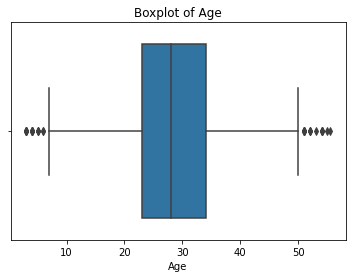

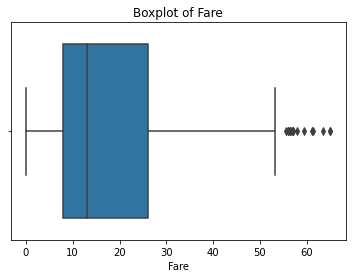

In [121]:
'''
for col in x_train[["Age","Fare"]]:
    sns.boxplot(x=x_train[col])
    plt.title(f"Boxplot of {col}")
    plt.show() #boxplot after handling outliers
    '''

array([[<AxesSubplot:title={'center':'Age'}>,
        <AxesSubplot:title={'center':'Fare'}>]], dtype=object)

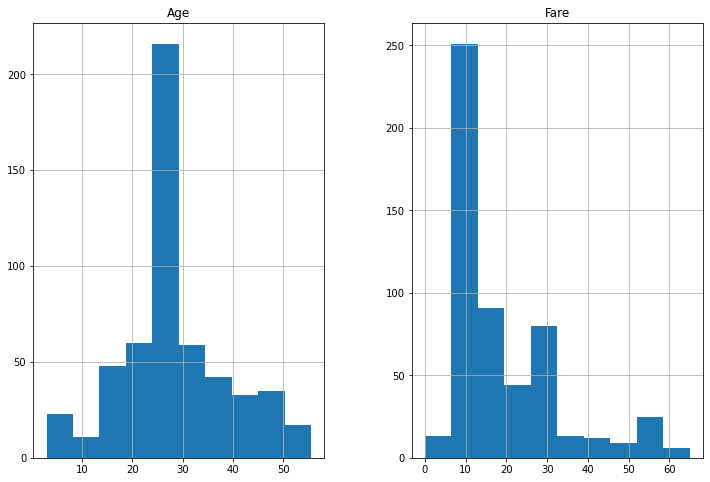

In [122]:
#x_train[["Age","Fare"]].hist(figsize=(12,8)) #histogram after handling outliers

# Data Transformation- Encoding
1. Label Encoding- used when feature has a natural order
from sklearn.preprocessing import LabelEncoder
df[]=LabelEncoder().fit_transform(df[])
2. One Hot Encoding/pd.get_dummies()- used when feature has no order
df_encoded = pd.get_dummies(df,columns=[],drop_first=True,dtype=int)
OR
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop=None)
encoded_array = encoder.fit_transform(df[])
3. Ordinal Encoding/map()- used when features have a meaningful order
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=[])
df[]=encoder.fit_transform(df[])
OR
ord_data={}
df[]=df[].astype(str).map(ord_data).astype(int)

For our data, OneHotEncoder/pd.get_dummies() will be used to transform Sex feature and Embarked feature and OrdinalEncoder/map() will be used to transform Pclass feature.

In [97]:
# apply on train and test separately
x_train = pd.get_dummies(x_train, columns=["Sex","Embarked","Pclass"], drop_first=True)
x_test  = pd.get_dummies(x_test, columns=["Sex","Embarked","Pclass"], drop_first=True)

# align test to train columns
x_train, x_test = x_train.align(
    x_test,
    join="left",
    axis=1,
    fill_value=0
)

In [98]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 486 to 821
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        668 non-null    object 
 1   Age         668 non-null    float64
 2   SibSp       668 non-null    int64  
 3   Parch       668 non-null    int64  
 4   Fare        668 non-null    float64
 5   Sex_male    668 non-null    bool   
 6   Embarked_Q  668 non-null    bool   
 7   Embarked_S  668 non-null    bool   
 8   Pclass_2    668 non-null    bool   
 9   Pclass_3    668 non-null    bool   
dtypes: bool(5), float64(2), int64(2), object(1)
memory usage: 34.6+ KB


# Feature Engineering-
1. create new features from existing ones- grouping the numerical columns like age.
2. interaction of features- make one column from two or more columns.
3. binning continuous variables- creating bins for columns like fare using pd.cut()

A new column called Family_Size to be created by combining SibSp and Parch. From this family size, is_alone feature is extracted to see if the passanger was alone or not. Title to be extracted from Name column which then manipulated to form Social_Ranking.

In [99]:
# Create interaction
x_train["Family_Size"] = x_train["SibSp"] + x_train["Parch"] + 1
x_test["Family_Size"]  = x_test["SibSp"]  + x_test["Parch"]  + 1

# Drop originals
x_train.drop(columns=["SibSp", "Parch"], inplace=True)
x_test.drop(columns=["SibSp", "Parch"], inplace=True)

In [100]:
x_train.groupby('Family_Size')["Family_Size"].count()

Family_Size
1     415
2     118
3      69
4      22
5      14
6      14
7      11
8       1
11      4
Name: Family_Size, dtype: int64

In [101]:
x_test.groupby('Family_Size')["Family_Size"].count()

Family_Size
1     122
2      43
3      33
4       7
5       1
6       8
7       1
8       5
11      3
Name: Family_Size, dtype: int64

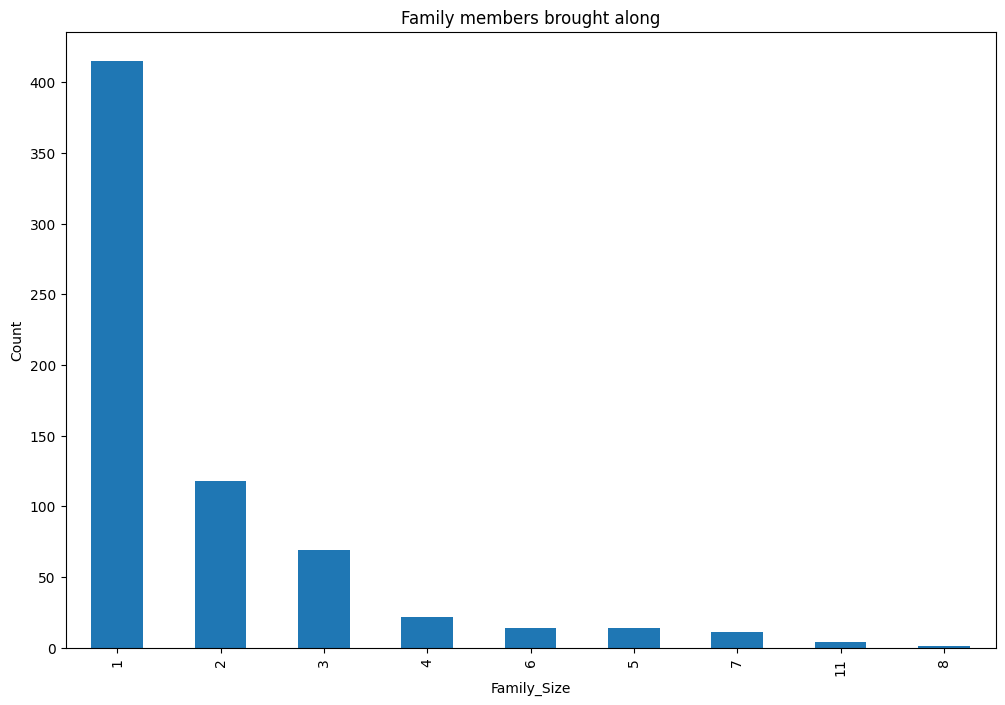

In [102]:
x_train["Family_Size"].value_counts().plot(kind="bar",figsize=(12,8))
plt.xlabel("Family_Size")
plt.ylabel("Count")
plt.title("Family members brought along")
plt.show()

In [103]:
#Extracting is_alone from family_size
x_train["Is_Alone"] = (x_train["Family_Size"] == 1).astype(int)
x_test["Is_Alone"]  = (x_test["Family_Size"] == 1).astype(int)

In [104]:
x_train.groupby('Is_Alone')["Is_Alone"].count()

Is_Alone
0    253
1    415
Name: Is_Alone, dtype: int64

In [105]:
x_test.groupby('Is_Alone')["Is_Alone"].count()

Is_Alone
0    101
1    122
Name: Is_Alone, dtype: int64

In [106]:
x_train["Title"]=x_train["Name"].str.extract(r"([A-Za-z]+)\.",expand=False).astype("category")
x_test["Title"]=x_test["Name"].str.extract(r"([A-Za-z]+)\.",expand=False).astype("category")

In [107]:
x_train.groupby("Title")["Title"].count()

Title
Col           2
Don           1
Dr            6
Jonkheer      1
Lady          1
Major         1
Master       28
Miss        133
Mlle          2
Mr          390
Mrs          97
Rev           5
Sir           1
Name: Title, dtype: int64

In [108]:
x_test.groupby("Title")["Title"].count()

Title
Capt          1
Countess      1
Dr            1
Major         1
Master       12
Miss         49
Mme           1
Mr          127
Mrs          28
Ms            1
Rev           1
Name: Title, dtype: int64

In [109]:
x_train["Title"]=x_train["Title"].replace(["Ms","Mlle"],"Miss")
x_test["Title"]=x_test["Title"].replace(["Ms","Mlle"],"Miss")
x_train["Title"]=x_train["Title"].replace("Mme","Mrs")
x_test["Title"]=x_test["Title"].replace("Mme","Mrs")

In [110]:
x_train["Title"]=x_train["Title"].replace(["Mr","Mrs","Miss","Master"],"Core_Titles")
x_test["Title"]=x_test["Title"].replace(["Mr","Mrs","Miss","Master"],"Core_Titles")
x_train["Title"]=x_train["Title"].replace(["Lady","Countess"],"Upper_Class_Female")
x_test["Title"]=x_test["Title"].replace(["Lady","Countess"],"Upper_Class_Female")
x_train["Title"]=x_train["Title"].replace(["Don","Jonkheer","Sir"],"Noble")
x_test["Title"]=x_test["Title"].replace(["Don","Jonkheer","Sir"],"Noble")
x_train["Title"]=x_train["Title"].replace(["Rev","Dr","Major","Col","Capt"],"Rare_Titles")
x_test["Title"]=x_test["Title"].replace(["Rev","Dr","Major","Col","Capt"],"Rare_Titles")
social_rank_map = {"Noble":1,"Upper_Class_Female":2,"Rare_Titles":3,"Core_Titles":4}
x_train['Social_Rank'] = x_train['Title'].map(social_rank_map)
x_test['Social_Rank'] = x_test['Title'].map(social_rank_map)

In [111]:
#Remove name and title
x_train.drop(["Name","Title"],axis=1,inplace=True)
x_test.drop(["Name","Title"],axis=1,inplace=True)

In [112]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 486 to 821
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Age          668 non-null    float64 
 1   Fare         668 non-null    float64 
 2   Sex_male     668 non-null    bool    
 3   Embarked_Q   668 non-null    bool    
 4   Embarked_S   668 non-null    bool    
 5   Pclass_2     668 non-null    bool    
 6   Pclass_3     668 non-null    bool    
 7   Family_Size  668 non-null    int64   
 8   Is_Alone     668 non-null    int32   
 9   Social_Rank  668 non-null    category
dtypes: bool(5), category(1), float64(2), int32(1), int64(1)
memory usage: 27.6 KB


In [113]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223 entries, 157 to 639
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Age          223 non-null    float64 
 1   Fare         223 non-null    float64 
 2   Sex_male     223 non-null    bool    
 3   Embarked_Q   223 non-null    bool    
 4   Embarked_S   223 non-null    bool    
 5   Pclass_2     223 non-null    bool    
 6   Pclass_3     223 non-null    bool    
 7   Family_Size  223 non-null    int64   
 8   Is_Alone     223 non-null    int32   
 9   Social_Rank  223 non-null    category
dtypes: bool(5), category(1), float64(2), int32(1), int64(1)
memory usage: 9.3 KB


In [114]:
x_train.shape, x_test.shape

((668, 10), (223, 10))

In [115]:
y_train.shape, y_test.shape

((668,), (223,))

# Function Transformation
df[].skew()
0 = perfect symmetry
> +1 = highly right skewed- use log, square root, cube root transformation
< -1 = highly left skewed- use squaring or raising to higher powers transformation
Common transformations-
1. Log- to reduce large values
2. Square Root- reduces variance and helps normalise data
3. Box-Cox- for positive values only.
4. Yeo-Johnson- for both positive and negative values
Lambda Function can be used for transformations-
log_tf = FunctionTransformer(func=lambda x: np.log1p(x))
sqrt_tf = FunctionTransformer(func=lambda x: np.sqrt(x))

Features with right skewness- fare
Features with left skewness- nil

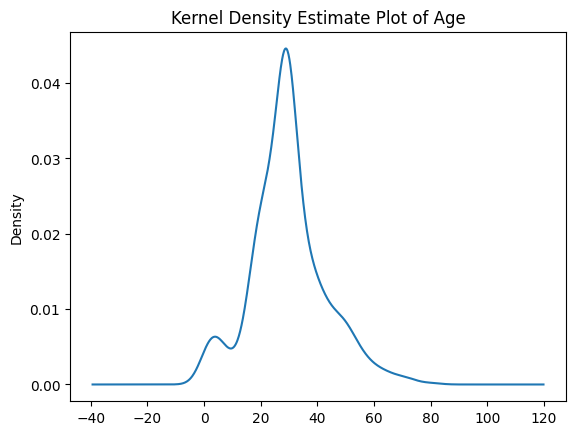

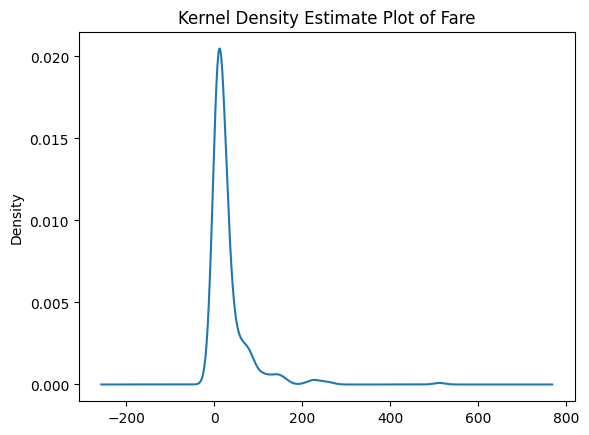

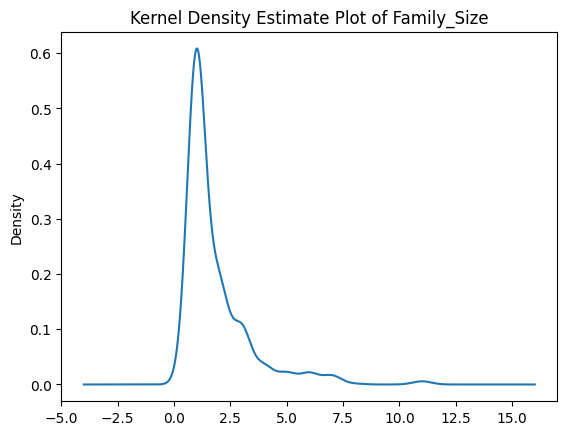

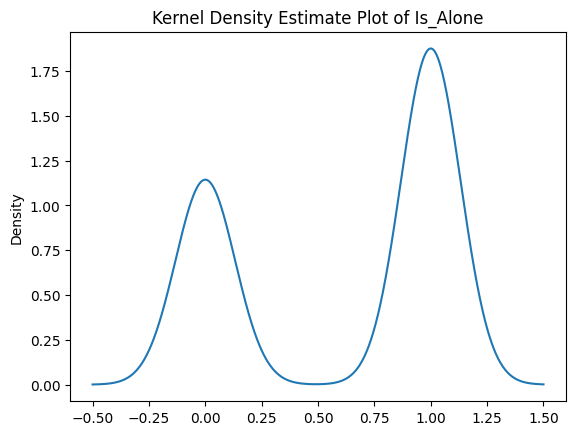

In [116]:
for col in x_train.select_dtypes(include=[int,float]):
    x_train[col].plot(kind="kde")
    plt.title(f"Kernel Density Estimate Plot of {col}")
    plt.show()

In [117]:
x_train["Family_Size"].skew(),x_test["Family_Size"].skew()

(2.723768814222596, 2.6042960963652018)

In [118]:
x_train["Fare"].skew(), x_test["Fare"].skew()

(4.845059411519961, 4.576857905201691)

In [119]:
#log transformation
x_train["Fare_log"]=np.log1p(x_train["Fare"])
x_test["Fare_log"]=np.log1p(x_test["Fare"])

In [120]:
x_train["Fare_log"].skew(), x_test["Fare_log"].skew()

(0.33151660810228295, 0.6170719046407349)

In [121]:
#Yeo_Johnson transformation
from sklearn.preprocessing import PowerTransformer
pt_YJ = PowerTransformer(method="yeo-johnson")
pt_YJ_fit = pt_YJ.fit(x_train[["Fare"]])
x_train["Fare_YJ"]=pt_YJ_fit.transform(x_train[["Fare"]])
x_test["Fare_YJ"]=pt_YJ_fit.transform(x_test[["Fare"]])

In [122]:
x_train["Fare_YJ"].skew(), x_test["Fare_YJ"].skew()

(-0.033277922231968134, 0.3205342920884523)

In [62]:
#On comparing the skewness among different transformations, it is seen that YJ transformation reduced the skewness better than others. Other columns to be dropped.

In [123]:
x_train.drop(["Fare","Fare_log"],axis=1,inplace=True)
x_test.drop(["Fare","Fare_log"],axis=1,inplace=True)

In [124]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 486 to 821
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Age          668 non-null    float64 
 1   Sex_male     668 non-null    bool    
 2   Embarked_Q   668 non-null    bool    
 3   Embarked_S   668 non-null    bool    
 4   Pclass_2     668 non-null    bool    
 5   Pclass_3     668 non-null    bool    
 6   Family_Size  668 non-null    int64   
 7   Is_Alone     668 non-null    int32   
 8   Social_Rank  668 non-null    category
 9   Fare_YJ      668 non-null    float64 
dtypes: bool(5), category(1), float64(2), int32(1), int64(1)
memory usage: 27.6 KB


In [125]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223 entries, 157 to 639
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Age          223 non-null    float64 
 1   Sex_male     223 non-null    bool    
 2   Embarked_Q   223 non-null    bool    
 3   Embarked_S   223 non-null    bool    
 4   Pclass_2     223 non-null    bool    
 5   Pclass_3     223 non-null    bool    
 6   Family_Size  223 non-null    int64   
 7   Is_Alone     223 non-null    int32   
 8   Social_Rank  223 non-null    category
 9   Fare_YJ      223 non-null    float64 
dtypes: bool(5), category(1), float64(2), int32(1), int64(1)
memory usage: 9.3 KB


# Class Imbalance Check
-After data cleaning, and train-test split
-for classification problems only, not regression
First check proportion, then calculate imbalance ratio.
1:1 Balanced
1.5-2:1 mild imbalance
2-5:1 moderate imbalance
5-10:1 severe imbalance
10-100:1 extreme imbalance
how to handle it-
logreg = LogisticRegression(class_weight="balance",max_iter=1000)
logreg.fit(x_train,y_train)

For our model, check for survived column as it is the target variable.

In [126]:
y_train.value_counts(normalize=True)*100

Survived
0    61.676647
1    38.323353
Name: proportion, dtype: float64

In [127]:
y_test.value_counts(normalize=True)*100

Survived
0    61.434978
1    38.565022
Name: proportion, dtype: float64

In [128]:
counts = y_train.value_counts()
ratio = counts.max()/counts.min()
print(f"Imbalance Ratio: {ratio:.2f}:1")

if ratio < 1.5:
    print("Balanced")
elif ratio < 5:
    print("Moderate Imbalanced")
else:
    print("Imbalanced")

Imbalance Ratio: 1.61:1
Moderate Imbalanced


In [129]:
counts = y_test.value_counts()
ratio = counts.max()/counts.min()
print(f"Imbalance Ratio: {ratio:.2f}:1")

if ratio < 1.5:
    print("Balanced")
elif ratio < 5:
    print("Moderate Imbalanced")
else:
    print("Imbalanced")

Imbalance Ratio: 1.59:1
Moderate Imbalanced


# Feature Scaling
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
1. Standard Scaler (Z-Score Normalisation)- to use when data is approximately normal and no significant outliers.
sts = StandardScaler()
sts.fit_transform(df)
2. Min_Max Scaler (Normalisation)- to use when bounded values [0,1] needed.
mms = MinMaxScaler()
mms.fit_transform(df)
3. Robust Scaler (Outlier-Resistant)- to use when there are many outliers.
rbs = RobustScaler()
rbs.fit_transform(df)

StandardScaler() to be used to scale Age, Fare_YJ and Family_Size_YJ columns.

In [130]:
x_train.columns

Index(['Age', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3',
       'Family_Size', 'Is_Alone', 'Social_Rank', 'Fare_YJ'],
      dtype='object')

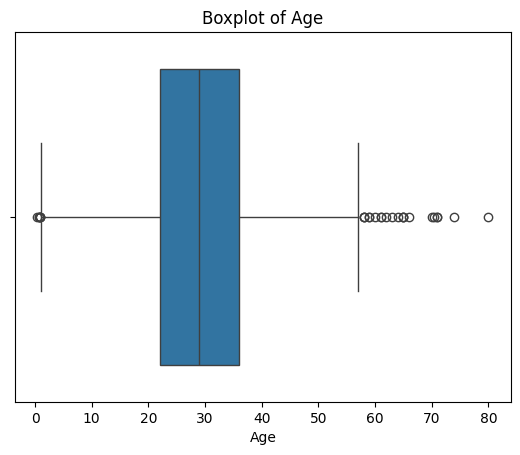

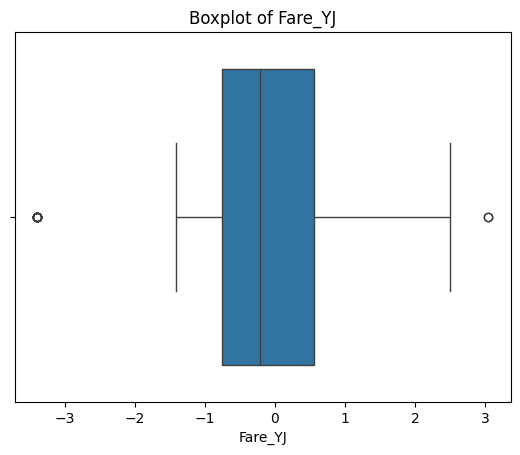

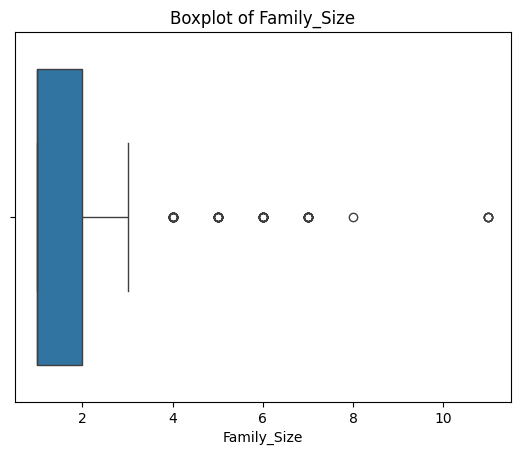

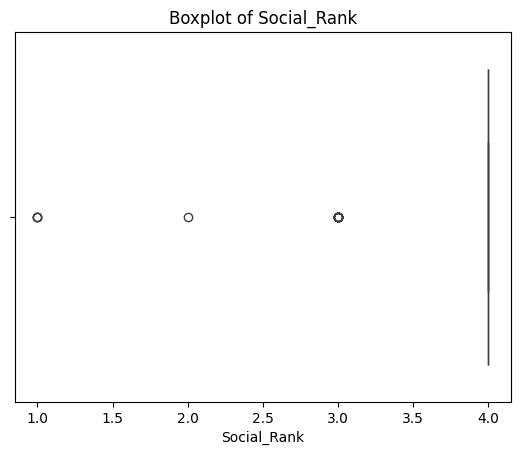

In [131]:
for col in x_train[["Age","Fare_YJ","Family_Size","Social_Rank"]]:
    sns.boxplot(x=x_train[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [132]:
from sklearn.preprocessing import StandardScaler
sts = StandardScaler()
sts.fit(x_train[["Age","Fare_YJ","Family_Size","Social_Rank"]])
x_train[["Age","Fare_YJ","Family_Size","Social_Rank"]]=sts.transform(x_train[["Age","Fare_YJ","Family_Size","Social_Rank"]])
x_test[["Age","Fare_YJ","Family_Size","Social_Rank"]]=sts.transform(x_test[["Age","Fare_YJ","Family_Size","Social_Rank"]])

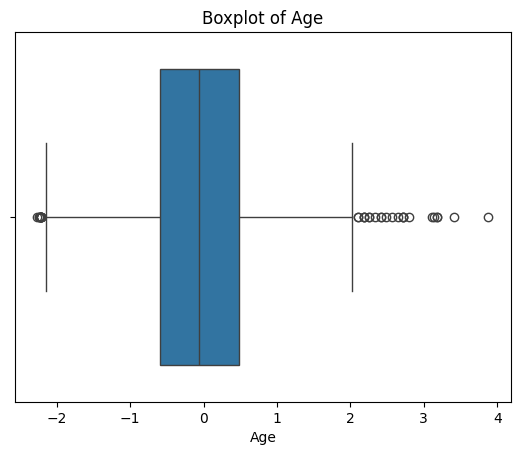

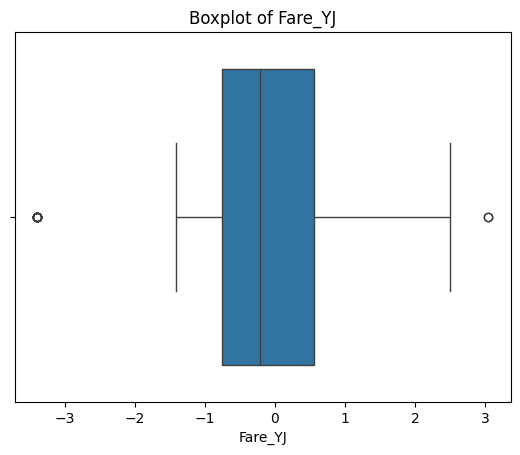

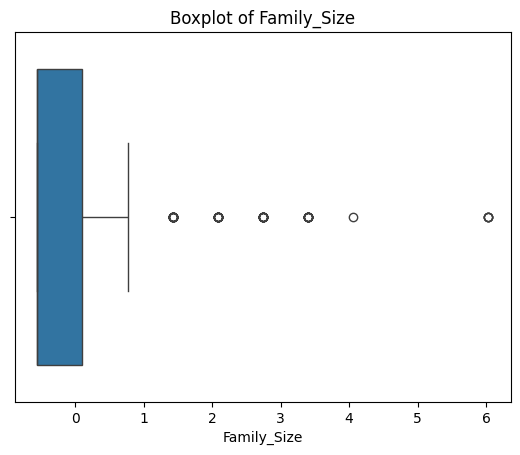

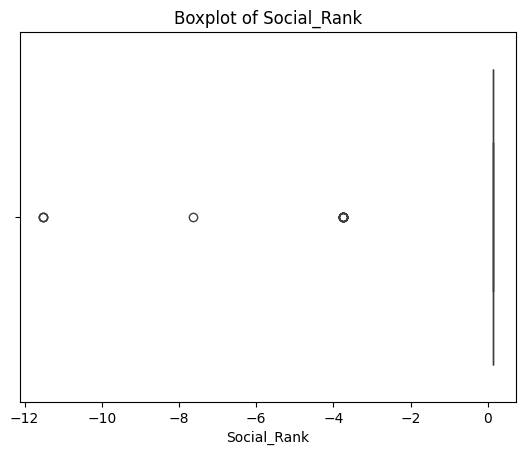

In [133]:
for col in x_train[["Age","Fare_YJ","Family_Size","Social_Rank"]]:
    sns.boxplot(x=x_train[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

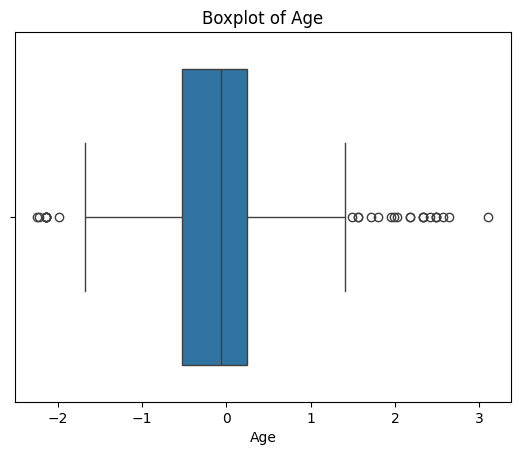

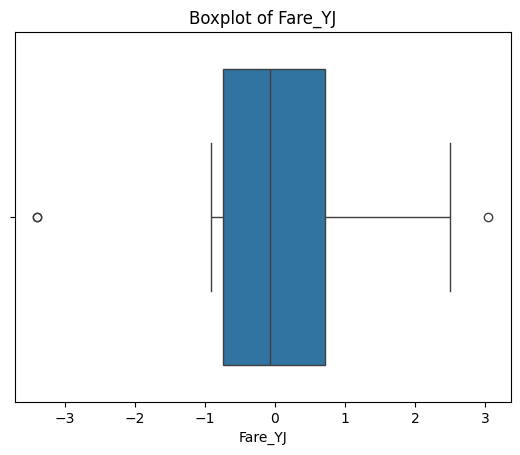

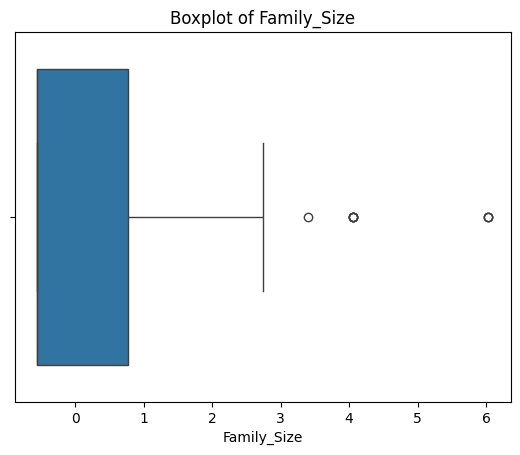

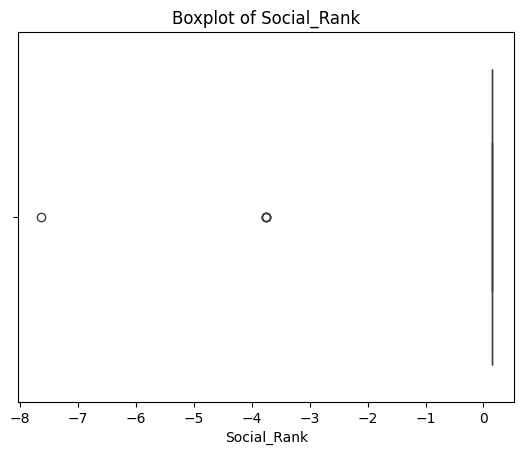

In [134]:
for col in x_test[["Age","Fare_YJ","Family_Size","Social_Rank"]]:
    sns.boxplot(x=x_test[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Feature Selection
1. Filter Methods- Correlation + Chi-square

Correlation- for numerical features. Very high correlation between features can lead to mullticolinearity. Very low correlation between feature and target means they're not important.
df.corr(numeric_only=True)["outcome"].sort_values(ascending)

Chi-Square- for categorical features. pvalue < 0.05 means significant relationship, pvalue >= 0.05 means insignificant relationship. Use minmaxscaler before as it requires non-negative values.
from sklearn.feature_selection import chi2
chi_scores,p_values = chi2(x,y)
chi_selected = x.columns[p_values <0.05].tolist()

2. Wrapper Method- Sequential Feature Selector

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

Forward Selection- starts with 0 features, picks n useful features
Backward Elimination- starts with all features, removes useless features and keep n features.

3. Embedded Method- LASSO (L1 Regularization)
if coefficient = 0, feature not important
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(x,y)
results = pd.DataFrame({"Feature":x.columns,"Coefficient":lasso.coef_})

4. Random Forest Regressor- can handle non-linear data
if coefficient = 0, feature not important
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x,y)
imp = pd.DataFrame({"Feature":x.columns,"Importance":rf.feature_importances_})

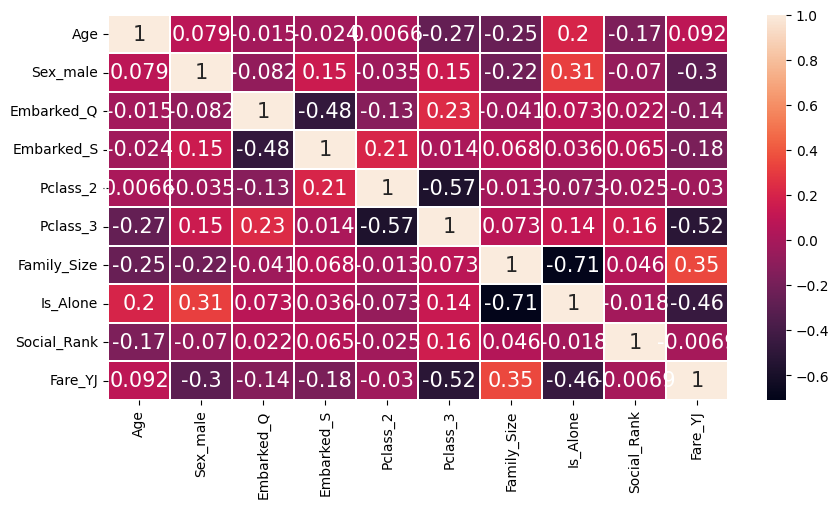

In [137]:
#Correlation- advice to remove Age/Age_Group, Fare_YJ/Fare_bins, SibSp_YJ/Family_Size_YJ, ParchYJ/Family_Size_YJ
corr = x_train.corr()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(corr,annot=True,annot_kws={'size': 15},linewidths=0.3)
plt.show()

In [138]:
#Correlation with target variable- advice to remove Age_Group
corr_values = x_train.corrwith(y_train)
print(corr_values)

Age           -0.083633
Sex_male      -0.557164
Embarked_Q     0.026042
Embarked_S    -0.180615
Pclass_2       0.060094
Pclass_3      -0.322090
Family_Size    0.050713
Is_Alone      -0.216091
Social_Rank   -0.005025
Fare_YJ        0.365260
dtype: float64


In [139]:
#Chi-Square- advice to keep the following list
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import chi2
scaler=MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train)
chi_scores,p_values = chi2(x_train_scaled,y_train)
chi_selected = x_train.columns[p_values <0.05].tolist()
chi_selected

['Sex_male', 'Embarked_S', 'Pclass_3', 'Is_Alone', 'Fare_YJ']

In [140]:
#wrapper method
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [141]:
#forward selection- advice to keep the following list
sfs_f = SequentialFeatureSelector(lr,n_features_to_select=6,direction="forward")
sfs_f.fit(x_train,y_train)

forward_selected = list(sfs_f.get_feature_names_out())
forward_selected

['Age', 'Sex_male', 'Embarked_Q', 'Pclass_3', 'Family_Size', 'Is_Alone']

In [142]:
#backward selection- advice to keep the following list
sfs_b = SequentialFeatureSelector(lr,n_features_to_select=6,direction="backward")
sfs_b.fit(x_train,y_train)

backward_selected = list(sfs_b.get_feature_names_out())
backward_selected

['Age', 'Sex_male', 'Embarked_Q', 'Pclass_3', 'Family_Size', 'Is_Alone']

In [143]:
#Embedded Methods- Lasso- advice to remove Age, Embarked_Q, Pclass_2, Parch_YJ, Fare_YJ, Family_Size_YJ
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(x_train,y_train)
results = pd.DataFrame({"Feature":x_train.columns,"Coefficient":lasso.coef_})
results

,Feature,Coefficient
0,Age,-0.052793
1,Sex_male,-0.457583
2,Embarked_Q,0.000000
3,Embarked_S,-0.031032
4,Pclass_2,-0.000000
5,Pclass_3,-0.138078
6,Family_Size,-0.049986
7,Is_Alone,-0.000000
8,Social_Rank,-0.001703
9,Fare_YJ,0.086911


In [144]:
#Random Forest Classifier-
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
imp = pd.DataFrame({"Feature":x_train.columns,"Importance":rf.feature_importances_})
imp

,Feature,Importance
0,Age,0.247230
1,Sex_male,0.256429
2,Embarked_Q,0.009366
3,Embarked_S,0.025268
4,Pclass_2,0.017192
5,Pclass_3,0.067284
6,Family_Size,0.064479
7,Is_Alone,0.017782
8,Social_Rank,0.007909
9,Fare_YJ,0.287060


In [145]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 486 to 821
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          668 non-null    float64
 1   Sex_male     668 non-null    bool   
 2   Embarked_Q   668 non-null    bool   
 3   Embarked_S   668 non-null    bool   
 4   Pclass_2     668 non-null    bool   
 5   Pclass_3     668 non-null    bool   
 6   Family_Size  668 non-null    float64
 7   Is_Alone     668 non-null    int32  
 8   Social_Rank  668 non-null    float64
 9   Fare_YJ      668 non-null    float64
dtypes: bool(5), float64(4), int32(1)
memory usage: 32.0 KB


In [146]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223 entries, 157 to 639
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          223 non-null    float64
 1   Sex_male     223 non-null    bool   
 2   Embarked_Q   223 non-null    bool   
 3   Embarked_S   223 non-null    bool   
 4   Pclass_2     223 non-null    bool   
 5   Pclass_3     223 non-null    bool   
 6   Family_Size  223 non-null    float64
 7   Is_Alone     223 non-null    int32  
 8   Social_Rank  223 non-null    float64
 9   Fare_YJ      223 non-null    float64
dtypes: bool(5), float64(4), int32(1)
memory usage: 10.7 KB


# Baseline Model
DummyClassifier used to get minimum acceptable score.

In [147]:
from sklearn.dummy import DummyClassifier
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(x_train,y_train)
baseline_score=baseline.score(x_test,y_test)*100
print(f"Baseline Accuracy: {baseline_score:.3f}")

Baseline Accuracy: 61.435


# Cross-Validation

In [148]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight="balanced")
cv_scores = cross_val_score(model,x_train,y_train,cv=5)
print(f"Cross-Val Accuracy:{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-Val Accuracy:0.8084 ± 0.0376


In [149]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight="balanced")
cv_scores = cross_val_score(model,x_train,y_train,cv=kf)
print(f"Cross-Val Accuracy:{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-Val Accuracy:0.8054 ± 0.0126


In [150]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight="balanced")
cv_scores = cross_val_score(model,x_train,y_train,cv=skf)
print(f"Cross-Val Accuracy:{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-Val Accuracy:0.7874 ± 0.0270


In [151]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight="balanced")
lr.fit(x_train,y_train)

LogisticRegression(class_weight='balanced')

In [152]:
lr.score(x_train,y_train), lr.score(x_test,y_test)

(0.7919161676646707, 0.7713004484304933)

In [153]:
#coefficient interpretation
pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": lr.coef_[0]
})

,Feature,Coefficient
0,Age,-0.500932
1,Sex_male,-2.453609
2,Embarked_Q,0.237126
3,Embarked_S,-0.281621
4,Pclass_2,-0.614897
5,Pclass_3,-1.356179
6,Family_Size,-0.520067
7,Is_Alone,-0.364731
8,Social_Rank,-0.051048
9,Fare_YJ,0.499652


In [154]:
# LR with degree 2
continuous_cols = ["Age", "Fare_YJ", "Family_Size"]

categorical_cols = [
    col for col in x_train.columns 
    if col not in continuous_cols
]

In [155]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

x_train_poly = poly.fit_transform(x_train[continuous_cols])
x_test_poly  = poly.transform(x_test[continuous_cols])

In [156]:
poly_feature_names = poly.get_feature_names_out(continuous_cols)

x_train_poly = pd.DataFrame(
    x_train_poly,
    columns=poly_feature_names,
    index=x_train.index
)

x_test_poly = pd.DataFrame(
    x_test_poly,
    columns=poly_feature_names,
    index=x_test.index
)

In [157]:
x_train_final = pd.concat(
    [x_train_poly, x_train[categorical_cols]],
    axis=1
)

x_test_final = pd.concat(
    [x_test_poly, x_test[categorical_cols]],
    axis=1
)

In [158]:
x_train_final.shape, x_test_final.shape

((668, 16), (223, 16))

In [159]:
lr_pf = LogisticRegression(class_weight="balanced")
lr_pf.fit(x_train_final,y_train)

LogisticRegression(class_weight='balanced')

In [160]:
lr_pf.score(x_train_final,y_train), lr_pf.score(x_test_final,y_test) #lower scores than LR with degree 1

(0.8023952095808383, 0.7802690582959642)

In [161]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

cm = confusion_matrix(y_test,lr.predict(x_test))
print(cm)

[[104  33]
 [ 18  68]]


In [162]:
precision = precision_score(y_test,lr.predict(x_test))
recall = recall_score(y_test,lr.predict(x_test))
f1score = f1_score(y_test,lr.predict(x_test))
roc_auc = roc_auc_score(y_test, lr.predict_proba(x_test)[:,1])
print("Precision: ",precision)
print("Recall: ",recall)
print("F1score: ",f1score)
print("ROC-AUC Score: ",roc_auc)

Precision:  0.6732673267326733
Recall:  0.7906976744186046
F1score:  0.7272727272727273
ROC-AUC Score:  0.8448905109489051


# Split in Classification
Pure Split- All 0s or 1s as split
Impure Split- Mixed 0s and 1s
Root should be the feature with fewer impure splits.

# Evaluating the model
To check model accuracy, class balance, performance metrics, model comparison, real-world readiness

In [164]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier() #default criteria is gini
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [165]:
dt.score(x_train,y_train), dt.score(x_test,y_test)

(0.9790419161676647, 0.7399103139013453)

In [166]:
dt1 = DecisionTreeClassifier(
criterion = "entropy",
max_depth = 3,
min_samples_split = 4,
min_samples_leaf = 2,
max_leaf_nodes = 5,
ccp_alpha = 0.01,
random_state = 42
)
dt1.fit(x_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.01, criterion='entropy', max_depth=3,
                       max_leaf_nodes=5, min_samples_leaf=2,
                       min_samples_split=4, random_state=42)

In [167]:
dt1.score(x_train,y_train), dt1.score(x_test,y_test)

(0.8083832335329342, 0.757847533632287)

In [168]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [169]:
rf.score(x_train,y_train),rf.score(x_test,y_test)

(0.9790419161676647, 0.7757847533632287)

In [170]:
rf1 = RandomForestClassifier(n_estimators=100,criterion="gini")
rf1.fit(x_train,y_train)

RandomForestClassifier()

In [171]:
rf1.score(x_train,y_train),rf1.score(x_test,y_test)

(0.9790419161676647, 0.7623318385650224)

In [172]:
rf2 = RandomForestClassifier(
n_estimators = 100,
criterion = "entropy",
max_depth = 5,
min_samples_split = 4,
min_samples_leaf = 2,
random_state = 42
)
rf2.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,
                       min_samples_split=4, random_state=42)

In [173]:
rf2.score(x_train,y_train),rf2.score(x_test,y_test)

(0.8577844311377245, 0.7937219730941704)

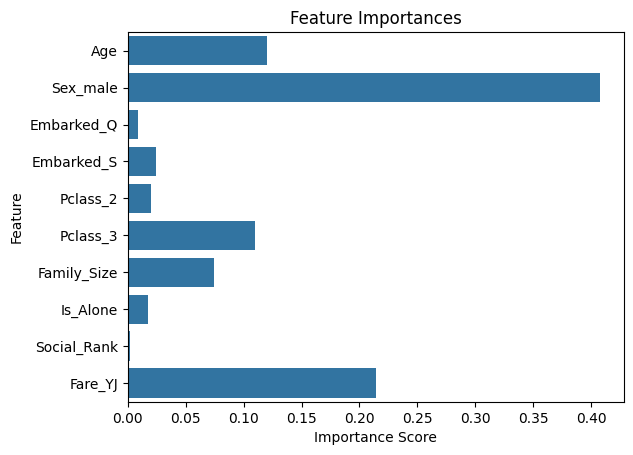

In [174]:
import seaborn as sns
importances = rf2.feature_importances_
sns.barplot(x=importances,y=x_train.columns)
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# Pruning
small ccp_alpha: bigger tree (more branches)
large ccp_alpha: smaller tree (more pruning)

# KNN Algorithm

In [175]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [176]:
knn.score(x_train,y_train), knn.score(x_test,y_test)

(0.8682634730538922, 0.757847533632287)

In [177]:
for k in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)
    
    train_score = knn.score(x_train,y_train)
    test_score = knn.score(x_test,y_test)
    
    print(f"k={k}: Train Accuracy = {train_score:.4f}, Test Accuracy = {test_score:.4f}")

k=1: Train Accuracy = 0.9671, Test Accuracy = 0.7130
k=2: Train Accuracy = 0.8772, Test Accuracy = 0.7399
k=3: Train Accuracy = 0.8817, Test Accuracy = 0.7803
k=4: Train Accuracy = 0.8548, Test Accuracy = 0.7892
k=5: Train Accuracy = 0.8683, Test Accuracy = 0.7578
k=6: Train Accuracy = 0.8608, Test Accuracy = 0.7668
k=7: Train Accuracy = 0.8503, Test Accuracy = 0.7623
k=8: Train Accuracy = 0.8338, Test Accuracy = 0.7758
k=9: Train Accuracy = 0.8383, Test Accuracy = 0.7892
k=10: Train Accuracy = 0.8383, Test Accuracy = 0.7713


In [178]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=9)

In [179]:
knn.score(x_train,y_train), knn.score(x_test,y_test)

(0.8383233532934131, 0.7892376681614349)

In [180]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test,knn.predict(x_test))
print(cm)

[[120  17]
 [ 30  56]]


In [181]:
precision = precision_score(y_test,knn.predict(x_test))
recall = recall_score(y_test,knn.predict(x_test))
f1score = f1_score(y_test,knn.predict(x_test))
print("Precision: ",precision)
print("Recall: ",recall)
print("F1score: ",f1score)

Precision:  0.7671232876712328
Recall:  0.6511627906976745
F1score:  0.7044025157232704
